Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
CC3084 - Data Science  

Cristian Tunchez (231359)  
Nadissa Vela (23764)

# Laboratorio 2: Deep Learning

## Inciso 2.14 — Un modelo LSTM alimentado con características de catch22

Los dos notebooks anteriores dejaron listo lo necesario para este último inciso:

- `01_lstm_series.ipynb` entrenó la mejor LSTM **univariada** sobre la serie total. Solo ve
  los 12 valores anteriores de la propia serie.
- `02_catch22.ipynb` mostró que las 22 características de catch22 resumen bien el
  comportamiento de una serie y determinó cuáles separan mejor.

Aquí se construye una LSTM **multivariada**. Además del valor del mes, recibe en cada paso un
puñado de características de catch22 calculadas sobre una ventana móvil. La pregunta que se intenta responder es si esa información extra la hace pronosticar mejor.

## Configuración del entorno

In [1]:
import sys
sys.path.append("../src")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
from IPython.display import display
from sklearn.preprocessing import StandardScaler

import data_utils as du
import lstm_utils as lu
import catch22_utils as c22
import ts_utils as tsu

SEMILLA = 42
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

pd.set_option("display.max_columns", 40)
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4),
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
})
MILES = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
print(f"PyTorch {torch.__version__} (CPU)")

PyTorch 2.13.0+cpu (CPU)


## 1. Punto de partida

Se trabaja sobre la serie **total**, con la misma partición, la misma transformación
(logaritmo, diferenciación, estandarización) y la misma configuración ganadora que encontró
el notebook 01. Todo eso se lee de los archivos que aquel notebook dejó en
`data/processed/`, así que los dos modelos que se comparan aquí son idénticos en todo salvo
en las variables de entrada.

In [2]:
CLAVE = "total"
ETIQUETA = "Total mensual de viajeros"
SEQ_LENGTH = 12

with open("../data/processed/mejor_config_lstm.json", encoding="utf-8") as f:
    guardado = json.load(f)[CLAVE]

CONFIG = guardado["config"]
EPOCAS_FINALES = guardado["epocas"]
print(f"Configuración ganadora del notebook 01: {CONFIG}")
print(f"Épocas del reentrenamiento final: {EPOCAS_FINALES}")
print(f"Su desempeño en la prueba (un paso adelante): "
      f"MAE = {guardado['mae_un_paso']:,.0f}   RMSE = {guardado['rmse_un_paso']:,.0f}")

serie, train, test = du.cargar_serie(CLAVE)
prep = lu.PreparadorSerie(serie, n_train=len(train), seq_length=SEQ_LENGTH, log=True)
partes = prep.dividir(inicio_val="2018-01-01", fin_val="2019-12-01")
print(f"\nVentanas -> ajuste: {len(partes['y_ajuste'])}, validación: {len(partes['y_val'])}, "
      f"entrenamiento completo: {len(partes['y_train'])}, prueba: {len(partes['y_test'])}")

Configuración ganadora del notebook 01: {'hidden_size': 20, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001}
Épocas del reentrenamiento final: 125
Su desempeño en la prueba (un paso adelante): MAE = 40,895   RMSE = 55,206

Ventanas -> ajuste: 95, validación: 24, entrenamiento completo: 134, prueba: 63


## 2. Características de catch22 en ventana móvil

En el notebook 02 se calculó **un solo vector de 22 números por serie**, que resume toda su
historia. Eso sirve para comparar series entre sí, pero no sirve como entrada de un modelo de
pronóstico.

Lo que sí sirve es calcular las características **sobre una ventana móvil**. Para cada mes, se
toman los 24 meses que terminan en él y se le aplican las 22 características. Así cada mes
recibe su propio vector, que describe cómo se venía comportando la serie hasta ese momento.

**Nota**: la ventana solo mira hacia atrás. Las características del mes *t* se
calculan con datos de *t* y anteriores, nunca posteriores, así que no se filtra información
del futuro.

In [3]:
VENTANA_C22 = 24   # dos años de historia para caracterizar cada mes

moviles = c22.catch22_movil(serie, ventana=VENTANA_C22)
print(f"Características móviles: {moviles.shape[0]} meses x {moviles.shape[1]} características")
display(moviles.iloc[[0, 23, 24, -1]].iloc[:, :5].style.format("{:.3f}"))

Características móviles: 210 meses x 22 características


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5
fecha,,,,,
2009-01-01 00:00:00,-0.236,-0.613,0.702,2.000,0.623
2010-12-01 00:00:00,-0.236,-0.613,0.702,2.000,0.623
2011-01-01 00:00:00,-0.267,-0.645,0.705,2.000,0.574
2026-06-01 00:00:00,0.403,-0.585,0.836,2.000,0.348


Los primeros 23 meses no tienen 24 meses de historia detrás, así que se rellenan con el
primer valor disponible. Como todos ellos caen dentro del tramo de ajuste, esto no afecta la
evaluación.

### ¿Cuáles características usar?

Meter las 22 como entrada multiplicaría por 23 el número de variables que la red tiene que procesar, con las mismas 95 ventanas de ajuste. Con tan pocos datos eso provocaría sobreajuste, así que se toman solo las **cinco más discriminantes** según el PCA del notebook 02, que son las que más información aportan sobre las diferencias de comportamiento.

In [4]:
N_CARACTERISTICAS = 5

importancia = pd.read_csv("../data/processed/importancia_catch22.csv", index_col=0)
SELECCION = list(importancia.index[:N_CARACTERISTICAS])

print("Características seleccionadas (las de mayor peso en PC1 y PC2):")
for nombre in SELECCION:
    print(f"  {importancia.loc[nombre, 'importancia']:.3f}   {nombre}")

Características seleccionadas (las de mayor peso en PC1 y PC2):
  0.361   DN_HistogramMode_5
  0.360   SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1
  0.358   FC_LocalSimple_mean1_tauresrat
  0.356   DN_OutlierInclude_p_001_mdrmd
  0.351   FC_LocalSimple_mean3_stderr


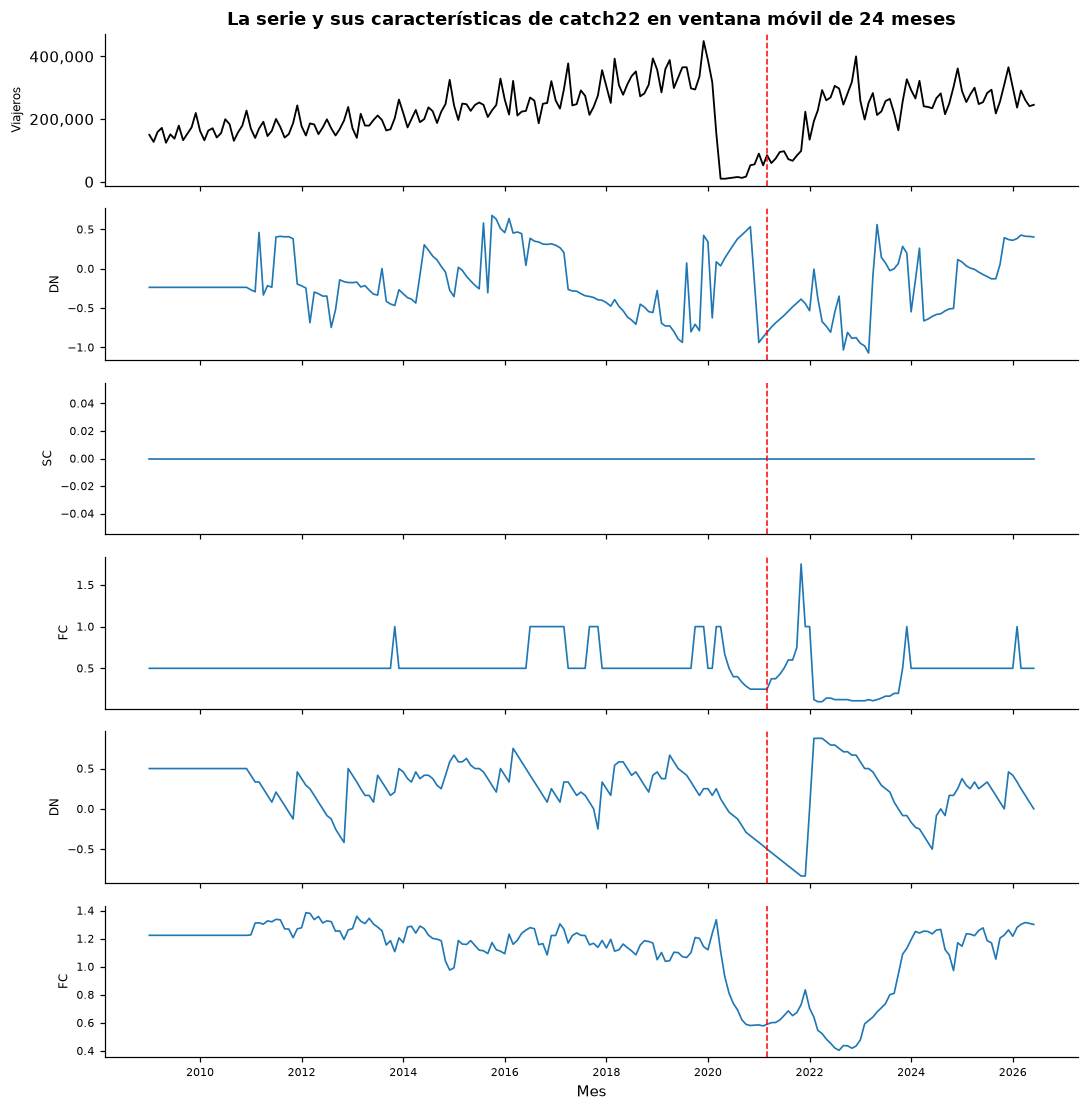

In [5]:
fig, ejes = plt.subplots(len(SELECCION) + 1, 1, figsize=(10, 1.7 * (len(SELECCION) + 1)), sharex=True)
ejes[0].plot(serie.index, serie.values, lw=1.2, color="black")
ejes[0].set_ylabel("Viajeros", fontsize=8)
ejes[0].yaxis.set_major_formatter(MILES)
ejes[0].set_title("La serie y sus características de catch22 en ventana móvil de 24 meses")
for eje, nombre in zip(ejes[1:], SELECCION):
    eje.plot(moviles.index, moviles[nombre], lw=1.1, color="C0")
    eje.set_ylabel(nombre.split("_")[0], fontsize=8)
    eje.tick_params(labelsize=7)
for eje in ejes:
    eje.axvline(train.index[-1], color="red", ls="--", lw=1)
ejes[-1].set_xlabel("Mes")
plt.tight_layout()
plt.show()

Se ve que las características cambian con el tiempo y reaccionan con fuerza al desplome de 2020.

## 3. Construcción de la entrada multivariada

La entrada de la LSTM univariada era, para cada ventana, una matriz de 12 filas (los meses) y
1 columna (la diferencia estandarizada). Ahora será de 12 filas y **6 columnas**: la misma
diferencia más las 5 características de catch22 de ese mes.

Las características también se estandarizan, y el escalador se ajusta **solo con el tramo de
entrenamiento**, igual que se hizo con la serie.

In [6]:
# La posición p de la serie z corresponde al mes p+1 de la serie original, así que
# la característica que acompaña al paso p es la del mes p+1: la última observada
# antes de hacer la predicción.
extras_crudos = moviles[SELECCION].values[1:]        # alineado con las posiciones de z

escalador_extras = StandardScaler().fit(extras_crudos[: prep.n_dif_train])
extras = escalador_extras.transform(extras_crudos).astype(np.float32)


def ventanas_multivariadas(prep, extras, posiciones):
    # Para cada objetivo, apila la diferencia estandarizada y las características
    # de los 12 meses de la ventana.
    bloques = []
    for p in posiciones:
        rango = np.arange(p - prep.seq_length, p)
        columna_z = prep.z[rango].reshape(-1, 1)
        bloques.append(np.hstack([columna_z, extras[rango]]))
    return np.array(bloques, dtype=np.float32)


partes_mv = {}
for tramo in ["ajuste", "val", "train", "test"]:
    partes_mv[f"x_{tramo}"] = ventanas_multivariadas(prep, extras, partes[f"pos_{tramo}"])
    partes_mv[f"y_{tramo}"] = partes[f"y_{tramo}"]
    partes_mv[f"pos_{tramo}"] = partes[f"pos_{tramo}"]

print(f"Entrada univariada:   {partes['x_ajuste'].shape}")
print(f"Entrada multivariada: {partes_mv['x_ajuste'].shape}   "
      f"(1 columna de la serie + {N_CARACTERISTICAS} de catch22)")

Entrada univariada:   (95, 12, 1)
Entrada multivariada: (95, 12, 6)   (1 columna de la serie + 5 de catch22)


## 4. Entrenamiento de los dos modelos

Para que la comparación sea limpia, ambos modelos usan **la misma arquitectura, la misma
semilla, el mismo tramo de ajuste, la misma validación y el mismo número de épocas**. Lo
único que cambia es el número de columnas de la entrada.

In [7]:
def entrenar_modelo(partes_datos, input_size, epocas_finales):
    # Etapa 1: ajuste + validación, para ver cuántas épocas conviene.
    torch.manual_seed(SEMILLA)
    modelo = lu.ModeloLSTM(input_size=input_size, hidden_size=CONFIG["hidden_size"],
                           num_layers=CONFIG["num_layers"], dropout=CONFIG["dropout"])
    historial = lu.entrenar(modelo, partes_datos["x_ajuste"], partes_datos["y_ajuste"],
                            partes_datos["x_val"], partes_datos["y_val"],
                            epocas=400, lr=CONFIG["lr"], batch_size=16,
                            paciencia=40, semilla=SEMILLA)
    # Etapa 2: reentrenamiento con todo el conjunto de entrenamiento.
    torch.manual_seed(SEMILLA)
    final = lu.ModeloLSTM(input_size=input_size, hidden_size=CONFIG["hidden_size"],
                          num_layers=CONFIG["num_layers"], dropout=CONFIG["dropout"])
    lu.entrenar(final, partes_datos["x_train"], partes_datos["y_train"],
                partes_datos["x_val"], partes_datos["y_val"],
                epocas=epocas_finales, lr=CONFIG["lr"], batch_size=16,
                paciencia=None, semilla=SEMILLA)
    return final, historial


modelo_uni, hist_uni = entrenar_modelo(partes, input_size=1, epocas_finales=EPOCAS_FINALES)
modelo_c22, hist_c22 = entrenar_modelo(partes_mv, input_size=1 + N_CARACTERISTICAS,
                                       epocas_finales=EPOCAS_FINALES)

print(f"LSTM univariada:   {lu.contar_parametros(modelo_uni):,} parámetros | "
      f"mejor MSE de validación = {hist_uni['mejor_val']:.4f} (época {hist_uni['mejor_epoca']})")
print(f"LSTM con catch22:  {lu.contar_parametros(modelo_c22):,} parámetros | "
      f"mejor MSE de validación = {hist_c22['mejor_val']:.4f} (época {hist_c22['mejor_epoca']})")

LSTM univariada:   1,861 parámetros | mejor MSE de validación = 0.0824 (época 124)
LSTM con catch22:  2,261 parámetros | mejor MSE de validación = 0.1225 (época 85)


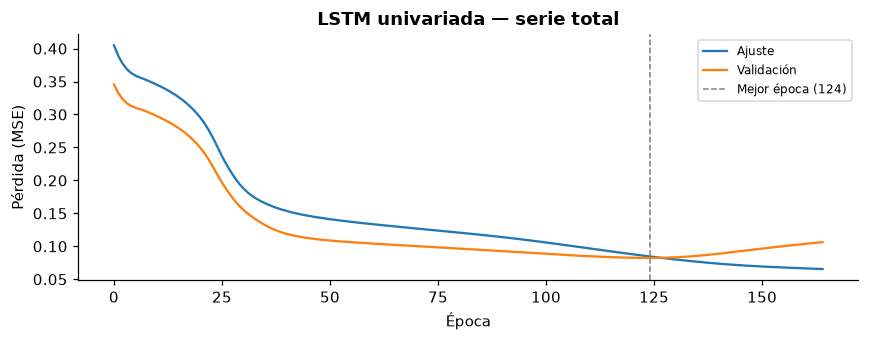

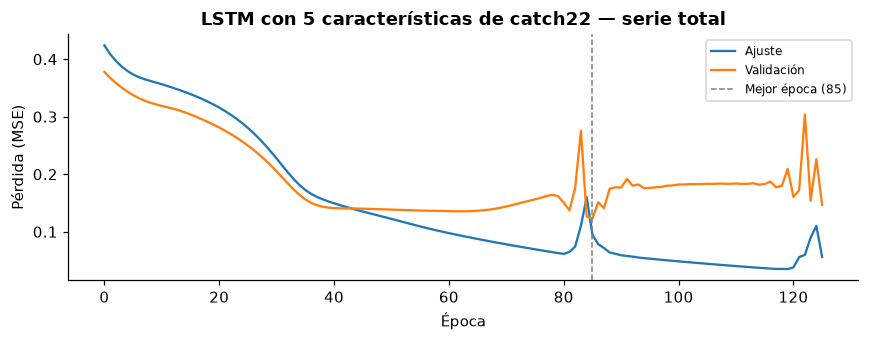

In [8]:
lu.graficar_perdidas(hist_uni, "LSTM univariada — serie total")
lu.graficar_perdidas(hist_c22, f"LSTM con {N_CARACTERISTICAS} características de catch22 — serie total")

## 5. Comparación sobre el conjunto de prueba

La comparación se hace **a un mes de horizonte**. El motivo es porque en modo recursivo el modelo con catch22 tendría que inventarse también las características futuras, recalculándolas sobre sus propias predicciones. Ese error se acumularía encima del error del pronóstico y lo que se estaría midiendo ya no sería el aporte de catch22, sino la velocidad a la que se degradan unas características simuladas. A un paso, los dos modelos reciben exactamente la misma información real y la única diferencia es si esa información incluye o no las
características.

In [9]:
resultados = {}
for nombre, modelo, datos_x in [
    ("LSTM univariada", modelo_uni, partes["x_test"]),
    (f"LSTM + catch22 ({N_CARACTERISTICAS} caract.)", modelo_c22, partes_mv["x_test"]),
]:
    z_pred = lu.predecir(modelo, datos_x)
    pred = prep.revertir_un_paso(z_pred, partes["pos_test"])
    resultados[nombre] = {"pred": pred, **tsu.evaluar(test.values, pred)}

tabla = pd.DataFrame([
    {"modelo": n, "MAE": r["MAE"], "RMSE": r["RMSE"],
     "MAE / nivel medio": r["MAE"] / test.mean()}
    for n, r in resultados.items()
])
display(tabla.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}",
                            "MAE / nivel medio": "{:.1%}"}).hide(axis="index"))

uni, c22_res = list(resultados.values())
cambio = (c22_res["RMSE"] - uni["RMSE"]) / uni["RMSE"] * 100
print(f"El modelo con catch22 tiene {abs(cambio):.1f}% "
      f"{'menos' if cambio < 0 else 'más'} RMSE que el univariado.")
tabla.to_csv("../data/processed/comparacion_lstm_catch22.csv", index=False)

modelo,MAE,RMSE,MAE / nivel medio
LSTM univariada,"40,895","55,206",16.9%
LSTM + catch22 (5 caract.),"80,556","99,768",33.3%


El modelo con catch22 tiene 80.7% más RMSE que el univariado.


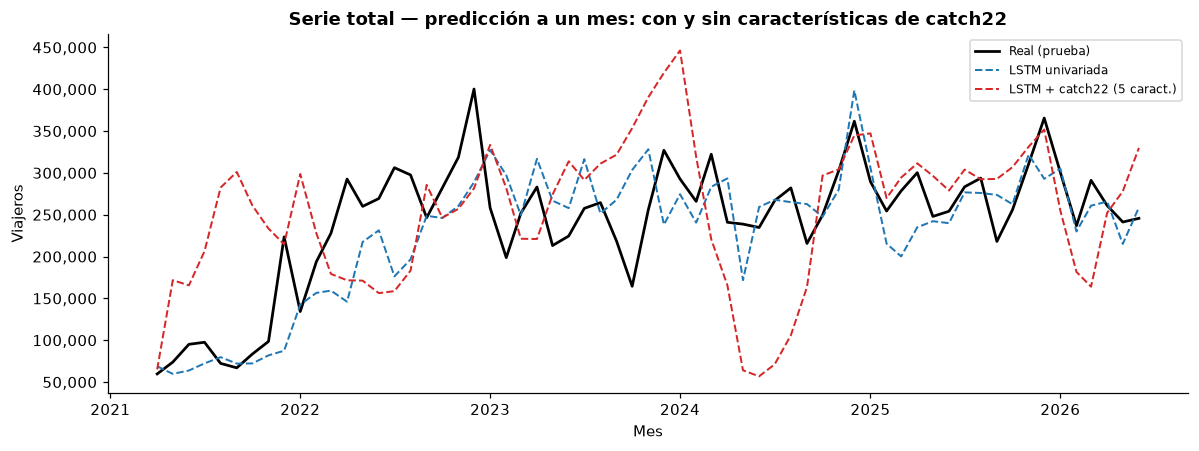

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(test.index, test.values, color="black", lw=1.8, label="Real (prueba)")
for (nombre, r), color in zip(resultados.items(), ["C0", "C3"]):
    ax.plot(test.index, r["pred"], ls="--", lw=1.3, color=color, label=nombre)
ax.set(title="Serie total — predicción a un mes: con y sin características de catch22",
       xlabel="Mes", ylabel="Viajeros")
ax.yaxis.set_major_formatter(MILES)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

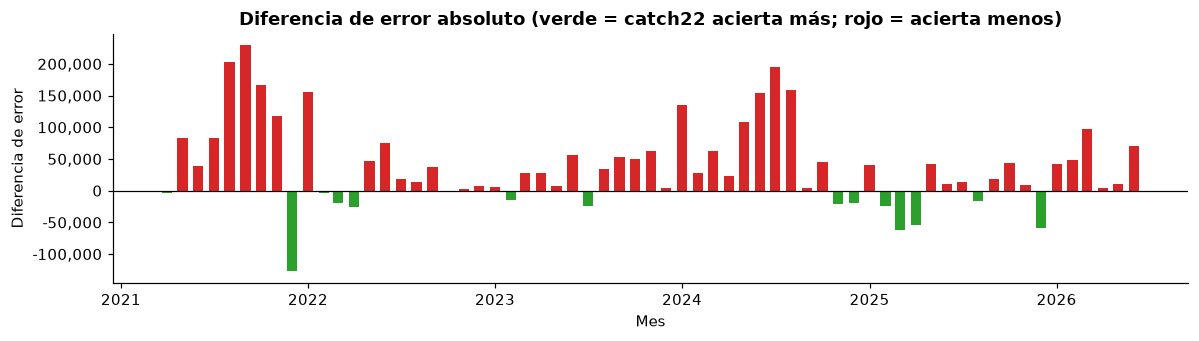

El modelo con catch22 gana en 15 de los 63 meses de prueba (24%).
Mes en que más ayuda:   2021-12 (-127,232)
Mes en que más estorba: 2021-09 (+229,058)


In [11]:
# ¿En qué meses ayuda y en cuáles estorba?
errores = pd.DataFrame({
    "real": test.values,
    "error univariada": np.abs(test.values - uni["pred"]),
    "error con catch22": np.abs(test.values - c22_res["pred"]),
}, index=test.index)
errores["diferencia"] = errores["error con catch22"] - errores["error univariada"]

fig, ax = plt.subplots(figsize=(11, 3.2))
colores = ["C2" if v < 0 else "C3" for v in errores["diferencia"]]
ax.bar(errores.index, errores["diferencia"], width=20, color=colores)
ax.axhline(0, color="black", lw=0.8)
ax.set(title="Diferencia de error absoluto (verde = catch22 acierta más; rojo = acierta menos)",
       xlabel="Mes", ylabel="Diferencia de error")
ax.yaxis.set_major_formatter(MILES)
plt.tight_layout()
plt.show()

mejores = (errores["diferencia"] < 0).sum()
print(f"El modelo con catch22 gana en {mejores} de los {len(errores)} meses de prueba "
      f"({mejores / len(errores):.0%}).")
print(f"Mes en que más ayuda:   {errores['diferencia'].idxmin():%Y-%m} "
      f"({errores['diferencia'].min():,.0f})")
print(f"Mes en que más estorba: {errores['diferencia'].idxmax():%Y-%m} "
      f"(+{errores['diferencia'].max():,.0f})")

## 6. Discusión de los resultados

**¿Qué se comparó?**

Dos LSTM idénticas en arquitectura, semilla, datos de entrenamiento, validación y número de épocas. La única diferencia es que una recibe por cada mes un solo número (el cambio respecto al mes anterior) y la otra recibe seis: ese mismo número más las cinco características de catch22 más discriminantes, calculadas sobre los 24 meses previos. Como control, el modelo univariado reentrenado aquí reproduce exactamente las métricas que el notebook 01 reportó, así que cualquier diferencia proviene únicamente de las variables nuevas.

**El resultado va en contra de lo esperado. Agregar catch22 empeoró el pronóstico.**

El RMSE aumentó de forma sustancial, el error relativo al nivel medio de la prueba pasó de alrededor de un sexto a un tercio, y el modelo con catch22 solo acierta más que el univariado en 15 de los 63 meses. No es un empate ni una mejora marginal, es un deterioro.

**¿Por qué ocurre?**

Hay tres razones concretas:

1. **Se multiplicó por seis el número de variables sin agregar un solo dato.** Siguen siendo
   95 ventanas de ajuste. Más columnas de entrada significan más pesos que ajustar con los
   mismos ejemplos, y por tanto más margen para aprender ruido. Es el mismo fenómeno que ya
   se había visto en el notebook 01, donde la red grande perdía contra la pequeña; aquí se
   confirma también en la validación, donde el modelo con catch22 quedó peor que el
   univariado antes siquiera de llegar a la prueba.

2. **Las características son en buena parte redundantes con la propia ventana.** La LSTM ya
   recibe los 12 meses anteriores. Variables como el error de predecir con el promedio de
   tres meses o la memoria de la autocorrelación se calculan *a partir de esa misma
   historia*, así que aportan poco que la red no pudiera deducir sola, pero sí ocupan
   capacidad del modelo.

3. **Las características se mueven muy despacio.** Al calcularse sobre ventanas de 24 meses,
   dos meses consecutivos comparten 23 meses de historia y sus valores son casi idénticos.
   Para la red son variables casi constantes de un mes al siguiente, aportan poco para
   distinguir un mes de otro, pero sí arrastran el nivel de la predicción cuando cambian de
   régimen. Eso explica que los peores desajustes se concentren en 2021, cuando la serie se
   estaba recuperando a toda velocidad y las características venían "cargadas" con los meses
   de cierre de fronteras que aún estaban dentro de su ventana de 24 meses.

**La conclusión de fondo es que son dos tareas distintas.**

catch22 fue diseñado para *describir y comparar* series completas, y en el notebook 02 hizo exactamente eso con buenos resultados. Resumió siete series en 22 números cada una y permitió agruparlas de forma interpretable. Pronosticar el siguiente valor de **una** serie es otro problema, y ahí la información relevante ya estaba en la ventana de 12 meses que la LSTM venía recibiendo. Que una representación sea buena para caracterizar no implica que sea buena como variable de entrada de un modelo predictivo.

**¿Qué implicaciones conlleva esta conclusión?**

Es un experimento sobre una sola serie, con una arquitectura fija y una sola elección de ventana móvil y de número de características. No demuestra que catch22 nunca ayude a pronosticar; muestra que, con estos datos, la información que aporta no compensa el costo de agregar cinco variables a un modelo que ya venía corto de datos. Con una serie mucho más larga, o usando las características para elegir entre modelos en vez de como
entrada, el resultado podría ser distinto.